# 二項分布の最尤推定による異常検知

計数データのうち、離散的な試行数$n$あたりの発生数$x$に異常検知を適用する場合、最尤推定した二項分布を正常のモデルとして用いた、教師なし学習に基づく異常検知手法が有用です。

典型例として、工場でのロットあたりの不良品数に異常検知を適用するケースが挙げられます。ロットあたりの生産製品数$n$は変動することが多く、その中に含まれる不良製品数$x$は、二項分布$Bi(x \mid n, \mu)$に従います。よって異常検知においても、二項分布を用いてモデリングすることが適切です。

ここでは以下の手順で、二項分布を用いた異常検知をPythonで実装します。

- A. モデルの学習
- B. 推論

今回は題材として、バスケットボールリーグにおける[スリーポイントシュート成功率のデータ](https://www.nba.com/stats/players/traditional)を用います。スポーツにおいてはこれ以外にも野球の打率等、「$n$回試行して$x$回成功したこと」を選手のパフォーマンス評価に利用する例が多く見られます。よって二項分布を用いたモデリングは、スポーツのデータ分析においても有用な手法と言えるでしょう。このような異常検知では、多くのケースにおいて「不利益をもたらす異常」を検知するというよりは、優れた選手の特定のような「有用な逸脱データ」を検出することを目的とします（ちょうど1章のお得な中古車のケースと目的が近い）。

今回使用するデータの例を以下に示します。

```csv
PLAYER_ID,AGE,FG3M,FG3A
203932,23.0,121,347
1628988,22.0,43,127
1627846,25.0,32,100
201143,33.0,73,203
202329,28.0,96,280
:
```

`PLAYER_ID`列が各選手を表すID、`AGE`列が年齢（今回は使用しない）、`FG3A`列がスリーポイントシュート試投数$n$、`FG3M`列が成功数$x$を表しており、2022年度のデータを学習用、2023年度のデータを推論用として用います。

## A. モデルの学習

学習フェーズでは、二項分布の発生率パラメータ$\mu$の推定値$\hat{\mu}$を、最尤推定で求めます。

ここで注意すべきは、選手ごとに真の成功率$\mu$が異なる、すなわち書籍5.2.3項で述べた過分散が発生していることが、ドメイン知識から明らかである点です。このような$\mu$が異なる各選手のデータをそのまま学習に用いると、二項分布モデルの前提である$\mu$が一定、すなわち過分散していないという条件を満たしません。
そこで今回は真の$\mu$が一定の擬似的な学習データとして、「2022年度のリーグ平均の成功率$35.4\%$を持つ架空の選手」を想定して、$\mu= 0.354$の二項分布からデータを1000個生成して使用します。このデータから学習したモデルは。平均的な選手よりも偶然の範囲を超えて成功率が高い（または低い）選手を検出します。一方で、選手ごとの真の成功率$\mu$の差もモデリング対象とし、能力のばらつきの範囲を超えて成功率が高い（または低い）選手を検出するモデルについては、8章で紹介するランダム効果を導入する方法を参照してください。

上記の考え方に基づく二項分布モデルの学習スクリプトを、以下のように実装します。

In [1]:
# コード5.1 二項分布の最尤推定による異常検知の実装例（学習）
import numpy as np
from scipy import stats

###### 学習データの生成######
# 試行数nを1000個生成（10〜500までのランダムな整数）
n_train = stats.randint.rvs(low=10, high=501, size=1000, random_state=42)
# 二項分布から発生数データxを1000個生成（真の発生率μ=0.354）
x_train = stats.binom.rvs(n=n_train, p=0.354, size=1000, random_state=42)

###### 学習ステップ1. 正常のモデルを作成する######
mu = np.sum(x_train) / np.sum(n_train) # 発生率パラメータμの最尤推定量

###### 学習ステップ2. 異常を表す指標（異常度）を定義する######
# 式を定義するのみでプログラム上は処理を実施しない

###### 学習ステップ3. 異常度にしきい値を設ける######
# 推論時に都度算出するので、学習時はしきい値を求めない

###### 学習で求めたパラメータを表示######
print(f"mu={mu}")

mu=0.3521293467815652


ここで求めた`mu`が、発生率パラメータの最尤推定量$\hat{\mu}$となります。学習データ（正常データ）に関して、試投数$n$を横軸、成功率$\frac{x}{n}$を縦軸にとった散布図をプロットしてみます。

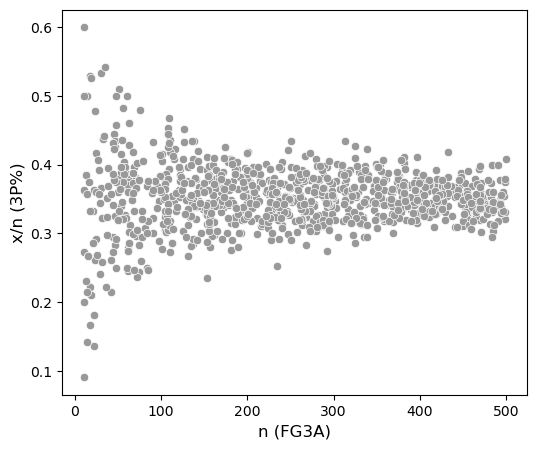

In [2]:
# 試行数nと成功率x/nの関係をプロット
import matplotlib.pyplot as plt
import seaborn as sns

# 成功率
mu_train = x_train / n_train
# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
# 分母nと成功率x/nの関係を描画
sns.scatterplot(x=n_train, y=mu_train, c='#999999', ax=ax)
ax.set_xlabel('n (FG3A)', fontsize=12)
ax.set_ylabel('x/n (3P%)', fontsize=12)
# グラフを表示
plt.show()

試投数$n$が少ないほど成功率$\frac{x}{n}$のばらつきが⼤きく、平均から外れた値が観測されやすいことがわかります。よって成功率$\frac{x}{n}$にしきい値を設けてしまうと、$n$が⼩さい選手ほど誤報が増えます。そのため、$n$に合わせてしきい値を変化させる必要があり、それを実現するために発生率パラメータの最尤推定量$\hat{\mu}$と二項分布モデルを用いて、推論時に動的にしきい値を決定します。

## B. 推論

学習フェーズで推定したパラメータ$\hat{\mu}$と推論データの試投数$n$を用いて、二項分布モデルに基づく以下の式を用いて上下のしきい値$x_{thh},x_{thl}$を求めます。

$x_{thh} = Bi_{CDF}^{-1}(1-0.00135 \mid n, \hat{\mu})$

$x_{thl} = Bi_{CDF}^{-1}(0.00135 \mid n, \hat{\mu})$

ここで、$Bi_{CDF}^{-1}$は二項分布の累積分布関数の逆関数を表し、$0.00135$はターゲットとする誤報率$0.0027\div 2$（両側判定なので2で割る必要がある）を表します。

このしきい値を用いて、以下のコードで推論データのシュート成功数$x$に対して異常判定を行います。

In [3]:
# コード5.2 二項分布の最尤推定による異常検知の実装例（推論）
import pandas as pd

###### 学習したパラメータをここに記載
MU=mu # 発生率パラメータμ

###### 推論データの読み込みと前処理######
# 2023年度のスリーポイントシュート成功率データを推論データとする
df_inference = pd.read_csv("./datasets/player_stats_2023.csv")
# 試投数5以下を除外（表示の都合上）
df_inference = df_inference[df_inference["FG3A"] > 0]
n_inference = df_inference["FG3A"].to_numpy() # 推論対象の試投数n
x_inference = df_inference["FG3M"].to_numpy() # 推論対象の成功数x

###### 推論を実行######
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
# 下側しきい値（二項分布の累積分布関数から計算）
th_lowers = stats.binom.ppf(TARGET_FP_RATE/2, n=n_inference, p=MU)
# 上側しきい値（二項分布の累積分布関数から計算）
th_uppers = stats.binom.ppf(1 - TARGET_FP_RATE/2, n=n_inference, p=MU)
# しきい値により異常の有無を判定
pred = np.where((x_inference < th_lowers) | (x_inference > th_uppers),
                "anomaly", "normal")
# 推論結果を表示（しきい値を超えた選手）
df_inference["3P%"] = x_inference / n_inference # 成功率
df_inference["prediction"] = pred
print(df_inference[df_inference["prediction"] == "anomaly"][
      ["PLAYER_ID", "3P%", "FG3A", "FG3M"]].sort_values(
      "3P%", ascending=False).reset_index(drop=True))

   PLAYER_ID       3P%  FG3A  FG3M
0    1628379  0.494424   269   133
1     201143  0.446154   325   145
2    1627763  0.444444   297   132
3    1630178  0.433604   369   160
4     201939  0.427230   639   273
5    1627741  0.425406   677   288
6     202691  0.411765   731   301


検出された選手は前年度のリーグ平均と比べ、偶然の範囲を超えてスリーポイントシュートの成功率が高い、あるいは低いと言えるでしょう。

今回の推論データでは、検出されたすべての選手がリーグ平均よりも高い成功率を持ち、上側のしきい値で検出されていることが分かります。ドメイン知識から考えると、成功率が低い選手が検出されにくい理由は、以下のように解釈できそうです。

- 成功率が低い選手はスリーポイントシュートを多く打たない傾向がある
- その結果、試投数$n$が小さくなり、下側しきい値も低くなる
- よって「低すぎる成功率」と判定される条件を満たしにくくなる

推論の結果、異常と判定される範囲を推論データと重ねて可視化してみます。

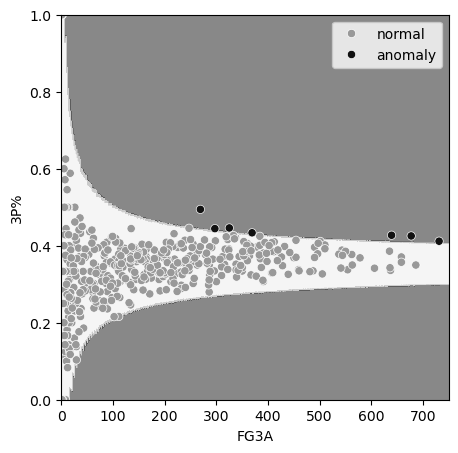

In [4]:
# 正常と異常の境界をプロット
import matplotlib.cm as cm
from sklearn.neighbors import NearestNeighbors

# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

###### 正常と異常の範囲を色分け ######
# (n,x)格子点を作成
n_list = np.arange(1, 751)
n_grid = np.array(sum([[n for x in range(n+1)] for n in n_list], []))
x_grid = np.array(sum([[x for x in np.arange(n+1)] for n in n_list], []))
mu_grid = x_grid / n_grid  # 観測された発生率μ'=x/n
# 下側しきい値（二項分布の累積分布関数から計算）
th_lowers = stats.binom.ppf(TARGET_FP_RATE/2, n=n_grid, p=MU)
# 上側しきい値（二項分布の累積分布関数から計算）
th_uppers = stats.binom.ppf(1 - TARGET_FP_RATE/2, n=n_grid, p=MU)
# しきい値判定
pred_grid = np.where((x_grid < th_lowers) | (x_grid > th_uppers),
                     0, 1)
# (n,μ)グリッドに判定を近似的に割り当てる
mu_list = np.linspace(0, 1, 500)
X1, X2 = np.meshgrid(n_list, mu_list)
X_neighbor = np.c_[X1.ravel(), X2.ravel()]
knn = NearestNeighbors(n_neighbors=1, algorithm='auto', metric='minkowski')
knn.fit(np.c_[n_grid, mu_grid])
distances, indices = knn.kneighbors(X_neighbor)
pred_neighbor = np.array([
    pred_grid[i]
    for i in indices
])
# 正常と異常の境界をプロット
pred_pivot = pred_neighbor.reshape(X1.shape)
ax.contourf(X1, X2, pred_pivot,
            cmap=cm.gray, alpha=0.5)

###### 各データを散布図としてプロット ######
sns.scatterplot(df_inference, x='FG3A', y='3P%', hue='prediction',
                palette=['#999999', '#111111'], ax=ax)
ax.set_xlim(0, 750)
ax.legend()
# グラフを表示
plt.show()

図からわかるように、試投数$n$が少ない選手は偶然の影響で高い（または低い）成功率を記録しやすいため、しきい値を$n$に応じて調整する必要があります。本コードでは、前項で述べた二項分布の累積分布関数に基づくしきい値を用いているため、$n$に応じた分布の変化に合わせて動的に調整できていることがわかります。この方法により、誤報率を一定に保ったまま、偶然の範囲を超えて高い、または低い成功率を記録した選手を検出できます。